# DeepLabV3+ Training (10-Band + Indices)

Train a pixel-wise DeepLabV3+ model on `new_dataset` (`*_img.tif` / `*_msk.tif`).

- Input: 16 features (`B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NDBI,MNDWI,BSI,DBI,NSI`)
- Target classes: 1..4 (`0` is ignored in loss/metrics)
- Output artifact: `best_deeplabv3plus_10b.pth`

In [5]:
import sys
!{sys.executable} -m pip install -q torch torchvision rasterio scikit-learn matplotlib pandas


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: c:\Users\user\.pyenv\pyenv-win\versions\3.12.2\python.exe -m pip install --upgrade pip


In [ ]:
from pathlib import Path
import random
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 39
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.benchmark = True
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PROJECT_DIR = Path(r'c:/satellite/project')
DATASET_DIR = PROJECT_DIR / 'new_dataset'
OUT_MODEL = PROJECT_DIR / 'best_deeplabv3plus_10b.pth'

CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_IDS = [1, 2, 3, 4]
EPS = 1e-6

EPOCHS = 3
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 3
EARLY_STOP_MIN_DELTA = 1e-4

IS_WINDOWS = (os.name == 'nt')
NUM_WORKERS = 0 if IS_WINDOWS else (2 if torch.cuda.is_available() else 0)
PIN_MEMORY = torch.cuda.is_available()
print(f'DataLoader settings -> num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}')

SPECTRAL_10_NAMES = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
INDEX_NAMES = ['NDVI','NDBI','MNDWI','BSI','DBI','NSI']
FEATURE_NAMES = SPECTRAL_10_NAMES + INDEX_NAMES

Device: cuda
GPU: NVIDIA GeForce RTX 4060
DataLoader settings -> num_workers=0, pin_memory=True


In [7]:
img_paths = sorted(DATASET_DIR.glob('*_img.tif'))
msk_paths = sorted(DATASET_DIR.glob('*_msk.tif'))

def sample_id(p: Path) -> str:
    return p.name.replace('_img.tif', '').replace('_msk.tif', '')

img_lookup = {sample_id(p): p for p in img_paths}
msk_lookup = {sample_id(p): p for p in msk_paths}
paired_ids = sorted(set(img_lookup) & set(msk_lookup))
pairs = [(img_lookup[sid], msk_lookup[sid]) for sid in paired_ids]

train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=RANDOM_STATE)

print(f'Paired samples: {len(pairs)}')
print(f'Train pairs: {len(train_pairs)} | Val pairs: {len(val_pairs)}')
print(f'Unmatched images: {len(set(img_lookup)-set(msk_lookup))}')
print(f'Unmatched masks: {len(set(msk_lookup)-set(img_lookup))}')

Paired samples: 3126
Train pairs: 2500 | Val pairs: 626
Unmatched images: 0
Unmatched masks: 0


In [8]:
def normalize_spectral_10(cube: np.ndarray) -> np.ndarray:
    x = cube[:10].astype(np.float32)
    probe = np.nanpercentile(x, 99)
    if probe > 2.0:
        x = np.clip(x / 10000.0, 0.0, 1.0)
    else:
        x = np.clip(x, 0.0, 1.0)
    return x

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    b2 = spectral_norm[0]
    b3 = spectral_norm[1]
    b4 = spectral_norm[2]
    b8 = spectral_norm[6]
    b8a = spectral_norm[7]
    b11 = spectral_norm[8]

    ndvi = (b8 - b4) / (b8 + b4 + EPS)
    ndbi = (b11 - b8) / (b11 + b8 + EPS)
    mndwi = (b3 - b11) / (b3 + b11 + EPS)
    bsi = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + EPS)
    dbi = ndbi - ndvi
    nsi = (b11 - b8a) / (b11 + b8a + EPS)

    return np.stack([ndvi, ndbi, mndwi, bsi, dbi, nsi], axis=0).astype(np.float32)

def build_deeplab_features(cube: np.ndarray) -> np.ndarray:
    spectral_norm = normalize_spectral_10(cube)
    indices = compute_spectral_indices(spectral_norm)
    return np.concatenate([spectral_norm, indices], axis=0).astype(np.float32)

class RasterSegDataset(Dataset):
    def __init__(self, pair_list, augment=False):
        self.pairs = pair_list
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        with rasterio.open(img_path) as src:
            image_cube = src.read().astype(np.float32)
        with rasterio.open(msk_path) as src:
            mask = src.read(1).astype(np.int64)

        x = build_deeplab_features(image_cube)
        y = mask

        if self.augment:
            if random.random() < 0.5:
                x = x[:, :, ::-1].copy()
                y = y[:, ::-1].copy()
            if random.random() < 0.5:
                x = x[:, ::-1, :].copy()
                y = y[::-1, :].copy()

        return torch.from_numpy(x), torch.from_numpy(y)

train_ds = RasterSegDataset(train_pairs, augment=True)
val_ds = RasterSegDataset(val_pairs, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

x0, y0 = train_ds[0]
print('Sample tensor:', x0.shape, y0.shape, 'mask classes:', torch.unique(y0).tolist())

Sample tensor: torch.Size([16, 256, 256]) torch.Size([256, 256]) mask classes: [3]


In [9]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, dilation=d, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch=256, rates=(1, 6, 12, 18)):
        super().__init__()
        self.b0 = ConvBNReLU(in_ch, out_ch, k=1, p=0)
        self.b1 = ConvBNReLU(in_ch, out_ch, k=3, p=rates[1], d=rates[1])
        self.b2 = ConvBNReLU(in_ch, out_ch, k=3, p=rates[2], d=rates[2])
        self.b3 = ConvBNReLU(in_ch, out_ch, k=3, p=rates[3], d=rates[3])
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            ConvBNReLU(in_ch, out_ch, k=1, p=0),
        )
        self.proj = ConvBNReLU(out_ch * 5, out_ch, k=1, p=0)

    def forward(self, x):
        size = x.shape[-2:]
        p = self.pool(x)
        p = F.interpolate(p, size=size, mode='bilinear', align_corners=False)
        x = torch.cat([self.b0(x), self.b1(x), self.b2(x), self.b3(x), p], dim=1)
        return self.proj(x)

class DeepLabV3PlusSmall(nn.Module):
    def __init__(self, in_ch=16, n_classes=5, base=64):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNReLU(in_ch, base, k=3, s=2, p=1),
            ConvBNReLU(base, base, k=3, s=1, p=1),
        )
        self.low = nn.Sequential(
            ConvBNReLU(base, base * 2, k=3, s=2, p=1),
            ConvBNReLU(base * 2, base * 2, k=3, s=1, p=1),
        )
        self.high = nn.Sequential(
            ConvBNReLU(base * 2, base * 4, k=3, s=2, p=1),
            ConvBNReLU(base * 4, base * 4, k=3, s=1, p=1),
            ConvBNReLU(base * 4, base * 4, k=3, s=1, p=1),
        )

        self.aspp = ASPP(base * 4, out_ch=256)
        self.low_proj = ConvBNReLU(base * 2, 48, k=1, p=0)
        self.decoder = nn.Sequential(
            ConvBNReLU(256 + 48, 256, k=3, p=1),
            ConvBNReLU(256, 256, k=3, p=1),
            nn.Conv2d(256, n_classes, kernel_size=1),
        )

    def forward(self, x):
        input_hw = x.shape[-2:]
        x = self.stem(x)
        low = self.low(x)
        high = self.high(low)

        y = self.aspp(high)
        y = F.interpolate(y, size=low.shape[-2:], mode='bilinear', align_corners=False)
        low_feat = self.low_proj(low)
        y = torch.cat([y, low_feat], dim=1)
        y = self.decoder(y)
        y = F.interpolate(y, size=input_hw, mode='bilinear', align_corners=False)
        return y

model = DeepLabV3PlusSmall(in_ch=len(FEATURE_NAMES), n_classes=5, base=64).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

sum(p.numel() for p in model.parameters())

5274213

In [10]:
def iou_per_class_np(y_true, y_pred, class_ids):
    out = {}
    for c in class_ids:
        inter = np.sum((y_true == c) & (y_pred == c))
        union = np.sum((y_true == c) | (y_pred == c))
        out[c] = inter / union if union > 0 else np.nan
    return out

def run_epoch(loader, training=True):
    model.train(training)
    losses = []
    all_true = []
    all_pred = []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(xb)
            loss = criterion(logits, yb)
            if training:
                loss.backward()
                optimizer.step()

        losses.append(loss.item())

        logits_eval = logits.detach().clone()
        logits_eval[:, 0, :, :] = -torch.inf
        pred = torch.argmax(logits_eval, dim=1)

        y_true_np = yb.detach().cpu().numpy()
        y_pred_np = pred.detach().cpu().numpy()

        valid = y_true_np != 0
        if np.any(valid):
            all_true.append(y_true_np[valid])
            all_pred.append(y_pred_np[valid])

    if len(all_true) == 0:
        return float(np.mean(losses)), np.nan, np.nan, {c: np.nan for c in CLASS_IDS}

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    ious = iou_per_class_np(y_true, y_pred, CLASS_IDS)
    miou = float(np.nanmean([ious[c] for c in CLASS_IDS]))
    acc = float(np.mean(y_true == y_pred))
    return float(np.mean(losses)), acc, miou, ious

In [11]:
history = []
best_miou = -1.0
best_state = None
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_miou, tr_ious = run_epoch(train_loader, training=True)
    va_loss, va_acc, va_miou, va_ious = run_epoch(val_loader, training=False)

    scheduler.step(va_miou if np.isfinite(va_miou) else 0.0)

    row = {
        'epoch': epoch,
        'train_loss': tr_loss,
        'train_acc': tr_acc,
        'train_miou': tr_miou,
        'val_loss': va_loss,
        'val_acc': va_acc,
        'val_miou': va_miou,
        'acc_gap_train_minus_val': (tr_acc - va_acc) if (np.isfinite(tr_acc) and np.isfinite(va_acc)) else np.nan,
        'lr': optimizer.param_groups[0]['lr'],
    }
    for c in CLASS_IDS:
        row[f'val_iou_{CLASS_NAMES[c]}'] = va_ious[c]
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} tr_mIoU={tr_miou:.4f} | "
        f"va_loss={va_loss:.4f} va_acc={va_acc:.4f} va_mIoU={va_miou:.4f} | "
        f"acc_gap={row['acc_gap_train_minus_val']:.4f}"
    )

    improved = np.isfinite(va_miou) and (va_miou > (best_miou + EARLY_STOP_MIN_DELTA))
    if improved:
        best_miou = va_miou
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(
            f"Early stopping at epoch {epoch}: no val mIoU improvement > {EARLY_STOP_MIN_DELTA} "
            f"for {EARLY_STOP_PATIENCE} consecutive epochs."
        )
        break

hist_df = pd.DataFrame(history)
hist_df.tail()

Epoch 01/20 | tr_loss=0.4856 tr_acc=0.8493 tr_mIoU=0.7329 | va_loss=0.2006 va_acc=0.9182 va_mIoU=0.8504 | acc_gap=-0.0688
Epoch 02/20 | tr_loss=0.2809 tr_acc=0.9025 tr_mIoU=0.8187 | va_loss=0.2542 va_acc=0.8647 va_mIoU=0.7552 | acc_gap=0.0378
Epoch 03/20 | tr_loss=0.2419 tr_acc=0.9171 tr_mIoU=0.8435 | va_loss=0.1606 va_acc=0.9368 va_mIoU=0.8760 | acc_gap=-0.0196
Epoch 04/20 | tr_loss=0.1974 tr_acc=0.9333 tr_mIoU=0.8694 | va_loss=0.1456 va_acc=0.9387 va_mIoU=0.8822 | acc_gap=-0.0054
Epoch 05/20 | tr_loss=0.1925 tr_acc=0.9368 tr_mIoU=0.8746 | va_loss=0.1472 va_acc=0.9450 va_mIoU=0.8927 | acc_gap=-0.0083
Epoch 06/20 | tr_loss=0.1912 tr_acc=0.9335 tr_mIoU=0.8702 | va_loss=0.1381 va_acc=0.9449 va_mIoU=0.8925 | acc_gap=-0.0114
Epoch 07/20 | tr_loss=0.1589 tr_acc=0.9429 tr_mIoU=0.8866 | va_loss=0.1507 va_acc=0.9465 va_mIoU=0.8954 | acc_gap=-0.0036
Epoch 08/20 | tr_loss=0.1630 tr_acc=0.9422 tr_mIoU=0.8857 | va_loss=0.1563 va_acc=0.9447 va_mIoU=0.8953 | acc_gap=-0.0026
Epoch 09/20 | tr_loss=0.1

,epoch,train_loss,train_acc,train_miou,val_loss,val_acc,val_miou,acc_gap_train_minus_val,lr,val_iou_Greenery,val_iou_Sand,val_iou_Water,val_iou_Cement
15,16,0.126107,0.956887,0.912599,0.092274,0.967462,0.932484,-0.010575,0.001,0.910046,0.962051,0.993505,0.864334
16,17,0.158686,0.947915,0.896029,0.120854,0.962129,0.922356,-0.014214,0.001,0.900191,0.953937,0.993322,0.841975
17,18,0.118802,0.956203,0.911658,0.119412,0.955418,0.907735,0.000784,0.001,0.846975,0.965947,0.993554,0.824464
18,19,0.103417,0.962905,0.924156,0.096252,0.968746,0.934539,-0.005841,0.001,0.908183,0.966407,0.991913,0.871651
19,20,0.123945,0.956739,0.912759,0.094874,0.966314,0.930468,-0.009576,0.001,0.913797,0.956316,0.993572,0.858186


In [12]:
if best_state is not None:
    model.load_state_dict(best_state)

payload = {
    'model_state_dict': model.state_dict(),
    'model_type': 'deeplabv3plus_small',
    'in_channels': len(FEATURE_NAMES),
    'num_classes': 5,
    'feature_names': FEATURE_NAMES,
    'class_names': CLASS_NAMES,
    'best_val_miou': float(best_miou),
    'config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'weight_decay': WEIGHT_DECAY,
        'early_stop_patience': EARLY_STOP_PATIENCE,
        'early_stop_min_delta': EARLY_STOP_MIN_DELTA,
        'random_state': RANDOM_STATE
    }
}

torch.save(payload, OUT_MODEL)
print('Saved:', OUT_MODEL)
print('Best val mIoU:', round(float(best_miou), 4))

Saved: c:\satellite\project\best_deeplabv3plus_10b.pth
Best val mIoU: 0.9345


              precision    recall  f1-score   support

    Greenery       0.95      0.95      0.95   8732455
        Sand       0.99      0.98      0.98  14544276
       Water       1.00      0.99      1.00   9367523
      Cement       0.92      0.94      0.93   8303751

    accuracy                           0.97  40948005
   macro avg       0.97      0.97      0.97  40948005
weighted avg       0.97      0.97      0.97  40948005



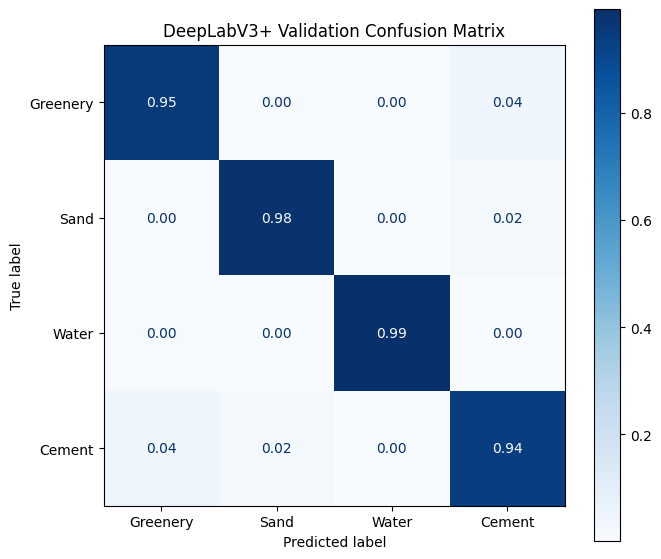

In [13]:
model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        logits[:, 0, :, :] = -torch.inf
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        y_true = yb.numpy()
        valid = y_true != 0
        if np.any(valid):
            all_true.append(y_true[valid])
            all_pred.append(pred[valid])

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print(classification_report(
    all_true,
    all_pred,
    labels=CLASS_IDS,
    target_names=[CLASS_NAMES[c] for c in CLASS_IDS],
    zero_division=0
))

cm = confusion_matrix(all_true, all_pred, labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=[CLASS_NAMES[c] for c in CLASS_IDS]).plot(ax=ax, cmap='Blues', values_format='.2f')
ax.set_title('DeepLabV3+ Validation Confusion Matrix')
plt.tight_layout()
plt.show()